In [1]:
import pandas as pd
#los datos proceden de una biblioteca del curso MOOC de ML de la UGR
gene_exp_inmune=pd.read_csv('https://drive.google.com/uc?id=1PYzEIdmnfjOnBpPDIFBE9hL1Lkj_OBCk', index_col=0)
clinical_info_inmune=pd.read_csv('https://drive.google.com/uc?id=1hHQfcvrFa5Jds-9tW_X4sHjKpYKdii9s', index_col=0)
X, y = gene_exp_inmune, clinical_info_inmune
X.head() #Me sirve para comprobar que se han cargado los datos correctamente

,COL2A1,RXRG,CCL19,SSX1,CST2,PRSS33,CDH2,SCUBE2,TMPRSS13,TRPM8,...,UBASH3A,GBP4,PRF1,PTK6,PCDHB2,GSDMA,DIO2,PLIN1,NCF1C,SLC7A11
0,-1.431141,-7.845756,0.665118,-1.409304,-2.537396,-1.676281,1.529957,-0.895042,-0.298778,5.091742,...,-0.659997,-1.469602,-0.570793,1.047635,-2.068966,-0.202828,-0.506767,1.285256,-0.901222,2.483020
1,-0.424374,-8.352423,0.386055,-2.846138,-0.685105,0.339787,-3.488043,-0.584982,5.679815,-1.117879,...,0.190202,-0.282190,0.375094,0.261662,3.356282,2.028145,-2.399010,-1.152801,0.662490,-2.914991
2,11.014251,0.415549,-1.633781,0.315442,-0.662332,-0.498761,0.535811,-0.467456,-2.818738,1.731049,...,-0.816305,-0.316202,-1.153745,-2.284201,-1.761597,-0.746975,-2.988195,-1.976877,-1.400889,-2.266779
3,-1.180446,-8.187415,-1.958023,5.061146,-2.603744,-0.666706,0.456460,-4.609624,-1.713164,-3.880876,...,0.214344,-0.327110,0.476764,1.153275,-0.337649,-1.006765,-2.686648,-1.329148,0.055994,-2.652313
4,0.816312,-1.189303,4.837235,4.972176,-2.963715,-2.665721,-0.268042,-1.740607,0.011610,-4.107467,...,3.352734,2.145368,3.358865,-2.324389,-1.741669,0.734312,-1.649316,6.284688,1.450729,1.131275


In [2]:
#Transformar el problema en uno de dos dimensiones
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
n_componentes = 2
pca=PCA(n_components=n_componentes)
#Visualizar el problema en dos dimensiones
X_2D=pca.fit_transform(X)
st=StandardScaler()
X_2D=st.fit_transform(X_2D)

In [3]:
#Validación Hold-out
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
y_int = pd.get_dummies(y).iloc[:,0]
X_2D_train, X_2D_test, y_int_train, y_int_test = train_test_split(X_2D, y_int, random_state=42)
print("Número de instancias en el conjunto de entrenamiento: {}; y test: {}".format(len(X_train), len(X_test)))

Número de instancias en el conjunto de entrenamiento: 252; y test: 84


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train.squeeze())
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Porcentaje de acierto: {:.2f}%".format(acc*100))

Porcentaje de acierto: 91.67%


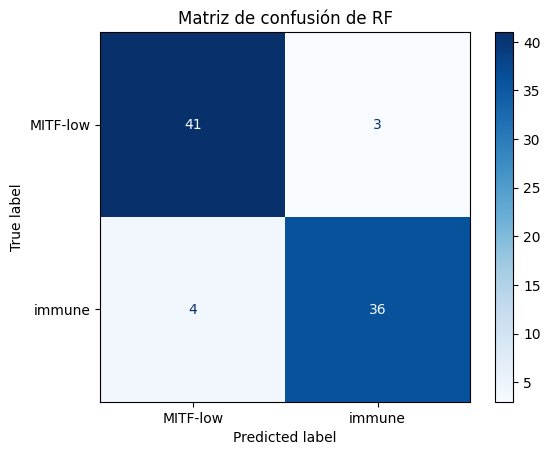

              precision    recall  f1-score   support

    MITF-low       0.91      0.93      0.92        44
      immune       0.92      0.90      0.91        40

    accuracy                           0.92        84
   macro avg       0.92      0.92      0.92        84
weighted avg       0.92      0.92      0.92        84

F1-score para RF: 0.91
AUC para RF: 0.97


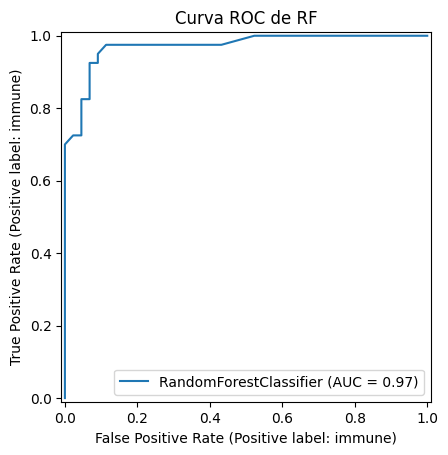

In [ ]:
#Métricas de evaluación
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

metrics.ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, cmap="Blues")
plt.title("Matriz de confusión de RF")
plt.show()

print(metrics.classification_report(y_test, y_pred))

f1 = metrics.f1_score(y_test, y_pred, pos_label='immune')
print("F1-score para RF: {:.2f}".format(f1))

y_probs = rf.predict_proba(X_test)
auc = metrics.roc_auc_score(y_test, y_probs[:, 1])
print("AUC para RF: {:.2f}".format(auc))
metrics.RocCurveDisplay.from_estimator(rf, X_test, y_test)
plt.title("Curva ROC de RF")
plt.show()
